In [1]:
import numpy as np
import os 
import sys
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator, LinearNDInterpolator as lndi

sys.path.append("/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/")

In [2]:
from util import get_mask_errs, get_spice_err
from skew_correction import skew_correct, deskew_linefit_window, full_correction
from skew_parameter_search import search_shifts, shift_holder, refine_points
from linefit_leastsquares import lsq_fitter, lsq_fitter
from linefit_storage import linefits
from plotting_modules import amplitude_plot, doppler_plot

fitter = lsq_fitter # lsq_fitter
from linefit_leastsquares import check_for_waves

In [3]:
spice_file = "~/work/spice_psf/spice_data/solo_L2_spice-n-ras_20220404T172032_V22_100664045-000.fits"

with fits.open(spice_file) as hdul:
    hdul.info()
    spice_hdr = hdul[3].header.copy()
    spice_dat = hdul[3].data[0].copy()
spice_dat = spice_dat.transpose([2,1,0]).astype(np.float32)

spice_dx, spice_dy, spice_dl = spice_hdr['CDELT1'],spice_hdr['CDELT2'],10*spice_hdr['CDELT3']
spice_wl0 = 10*spice_hdr['CRVAL3']-spice_dl*spice_hdr['CRPIX3']
spice_la = spice_wl0+spice_dl*np.arange(spice_dat.shape[2],dtype=np.float64)

Filename: /cluster/home/zhuyin/work/spice_psf/spice_data/solo_L2_spice-n-ras_20220404T172032_V22_100664045-000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  Mg IX 706 - Peak    1 PrimaryHDU     416   (96, 836, 50, 1)   float32   
  1  Ne VIII 770 - Peak    1 ImageHDU       416   (96, 836, 25, 1)   float32   
  2  Ne VIII 780    1 ImageHDU       418   (96, 836, 25, 1)   float32   
  3  S V 786 (Merged)    1 ImageHDU       426   (96, 836, 64, 1)   float32   
  4  C III 977 - Peak    1 ImageHDU       416   (96, 836, 17, 1)   float32   
  5  Ly Beta 1025 (Merged)    1 ImageHDU       423   (96, 836, 31, 1)   float32   
  6  O VI 1032 - Peak    1 ImageHDU       417   (96, 836, 34, 1)   float32   
  7  O VI 1037 (Merged)    1 ImageHDU       424   (96, 836, 62, 1)   float32   
  8  VARIABLE_KEYWORDS    1 BinTableHDU    411   1R x 29C   [96D, 96I, 96I, 96I, 96I, 96I, 96E, 96E, 96E, 96E, 3I, 3I, 3I, 3I, 3J, 3J, 3J, 3J, 2208A, 96D, 96D, 50D, 25D, 25D, 64D, 17D, 31D, 34D,

In [6]:
spice_dat.shape

(96, 832, 50)

In [4]:
linelist = {'C III 977':977.0}

line_names = list(linelist.keys())
line_waves = [linelist[name] for name in line_names]

centers, lines = check_for_waves(spice_la)

xl, xh, yl, yh = [-5,5,-5,5]
xs_initial, ys_initial = np.array(np.meshgrid(np.linspace(xl,xh,5),np.linspace(yl,yh,5))).transpose([0,2,1])

print(xs_initial, ys_initial)

shift_vars = shift_holder(spice_dat, spice_hdr, fitter.__name__, save_dir='/cluster/home/zhuyin/work/spice_psf/spice_skew_20220306/',
                          linelist=linelist)

[[-5.  -5.  -5.  -5.  -5. ]
 [-2.5 -2.5 -2.5 -2.5 -2.5]
 [ 0.   0.   0.   0.   0. ]
 [ 2.5  2.5  2.5  2.5  2.5]
 [ 5.   5.   5.   5.   5. ]] [[-5.  -2.5  0.   2.5  5. ]
 [-5.  -2.5  0.   2.5  5. ]
 [-5.  -2.5  0.   2.5  5. ]
 [-5.  -2.5  0.   2.5  5. ]
 [-5.  -2.5  0.   2.5  5. ]]


In [7]:
sv_initial = search_shifts(spice_dat, spice_hdr, xs_initial, ys_initial,
                           lsq_fitter, search_multi_thread=True, search_nthread=36,
                           yrange_plot_dir='/cluster/home/zhuyin/work/spice_psf/spice_skew_20220306/yrange_plots/',
                           shift_vars=shift_vars)

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarn

In [15]:
raw_results_CIII = full_correction(spice_dat, spice_hdr, 0, 0, nthreads=12, linelist=linelist)

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


In [16]:
def correction_preview(best_correction_results):
    plt_linefits = best_correction_results['linefits']
    ymin,ymax = best_correction_results['ymin'],best_correction_results['ymax']
    line_name = list(plt_linefits[0].keys())[0]
    date = plt_linefits[0][0]['amplitudes'].meta['DATE-OBS']

    fig=plt.figure(figsize=[16,8])
    gs = fig.add_gridspec(nrows=2,ncols=2,width_ratios=[1,1],height_ratios=[7,1])
    cbaxes = [fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]
    axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]

    plt.suptitle('Corrected fits for '+line_name+' at '+date)
    amplitude_plot(plt_linefits[0][0],axis=axes[0], cbaxis=cbaxes[0], ymin=ymin, ymax=ymax)
    doppler_plot(plt_linefits[0][0],axis=axes[1], cbaxis=cbaxes[1], doppmin=-0.075, doppmax=0.075, ymin=ymin,ymax=ymax)
    axes[1].set(title='Doppler; best xshift, yshift='+str(best_correction_results['xlshift'])+','+str(best_correction_results['ylshift']))

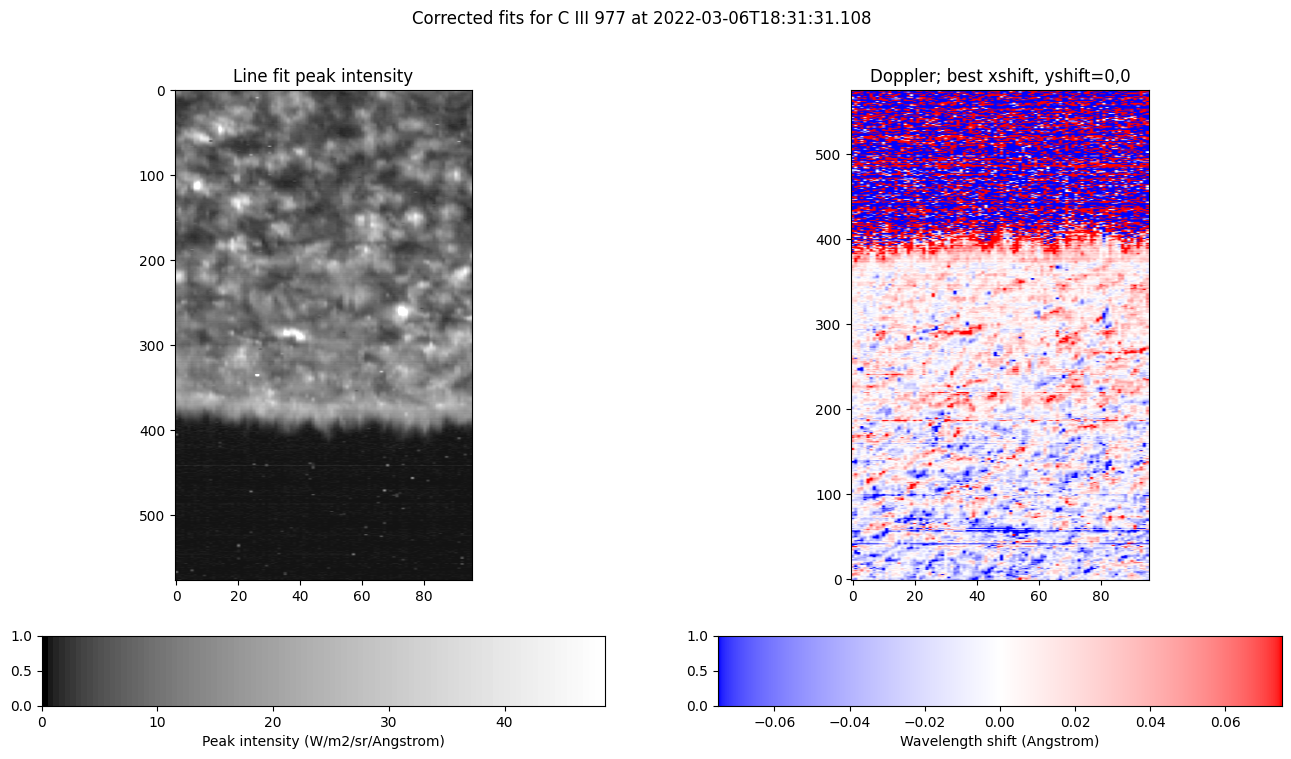

In [17]:
correction_preview(raw_results_CIII)